# Receptive Field Demo

With sliding window of size `w`, a single layer only sees `w` tokens. But information propagates *across layers*: after `L` layers, a token can transitively reach tokens up to `L * w` positions away.

This notebook visualizes that propagation. **No exercises here.**

## Setup

In [1]:
import torch
import matplotlib.pyplot as plt

## 1. Reachability matrix

For a stack of `L` sliding-window layers with window `w`, compute a reachability matrix: `R[i, j] == True` iff position `j` can influence position `i` after `L` layers.

In [2]:
def sliding_window_mask(seq_len, window_size):
    """M[i, j] = True iff position i (causally) attends to position j in ONE layer."""
    diff = torch.arange(seq_len)[:, None] - torch.arange(seq_len)[None, :]
    return torch.where((diff >= window_size) | (diff < 0), False, True)


# Single-layer mask, seq_len=8, w=3 — direct attention pattern
sliding_window_mask(8, 3)

tensor([[ True, False, False, False, False, False, False, False],
        [ True,  True, False, False, False, False, False, False],
        [ True,  True,  True, False, False, False, False, False],
        [False,  True,  True,  True, False, False, False, False],
        [False, False,  True,  True,  True, False, False, False],
        [False, False, False,  True,  True,  True, False, False],
        [False, False, False, False,  True,  True,  True, False],
        [False, False, False, False, False,  True,  True,  True]])

In [3]:
def reachability(seq_len, window_size, n_layers):
    """R[i, j] = True iff input at position j can influence position i after L layers.

    Composition: after 2 layers, i is reachable from j if there exists some
    intermediate k such that (layer 2: i <- k) AND (layer 1: k <- j).
    That's boolean matrix multiplication.

    Since the diagonal of M is True (a token attends to itself), composing M
    with itself L times gives 'reachable in at most L hops' directly.
    """
    M = sliding_window_mask(seq_len, window_size)
    reach = M.clone()
    for _ in range(n_layers - 1):
        reach = (reach.float() @ M.float()) > 0
    return reach


# Sanity: at L=1, reachability is just the single-layer mask
M1 = sliding_window_mask(16, 3)
R1 = reachability(16, 3, 1)
assert torch.equal(M1, R1)

# At L=4, reach band is wider — print the row for query position 12
R4 = reachability(16, 3, 4)
print('Single layer  (L=1), pos 12 can see:', torch.where(R1[12])[0].tolist())
print('After 4 layers (L=4), pos 12 can see:', torch.where(R4[12])[0].tolist())

Single layer  (L=1), pos 12 can see: [10, 11, 12]
After 4 layers (L=4), pos 12 can see: [4, 5, 6, 7, 8, 9, 10, 11, 12]


## 2. Plot reachability for various depths

Show `R` as a heatmap for `L = 1, 2, 4, 8` with fixed `w = 3`. The diagonal band should grow wider as `L` increases.

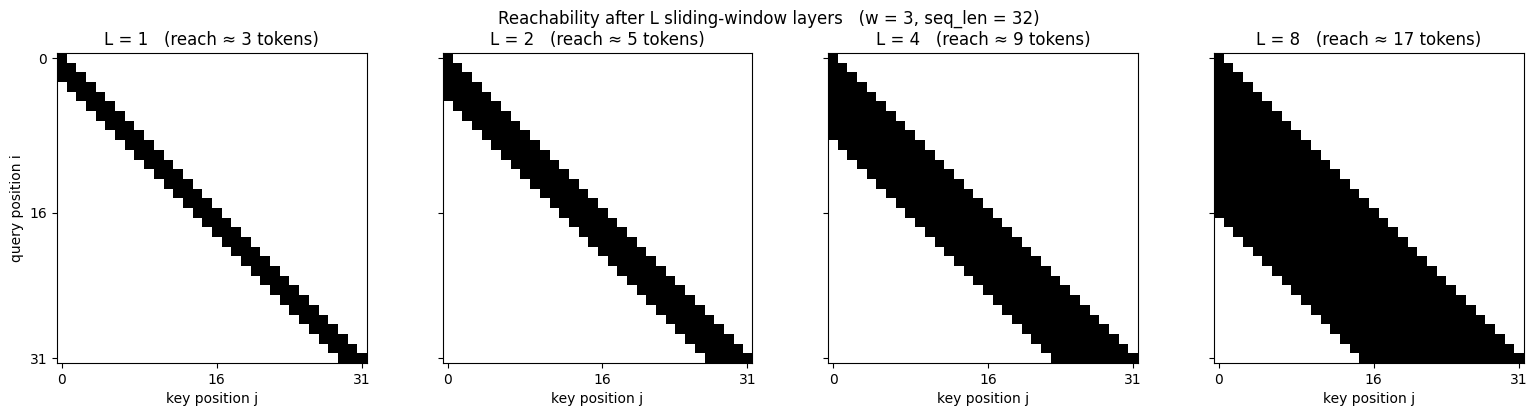

In [4]:
seq_len = 32
w       = 3
depths  = [1, 2, 4, 8]

fig, axes = plt.subplots(1, len(depths), figsize=(16, 4), sharey=True)

for ax, L in zip(axes, depths):
    R = reachability(seq_len, w, L).int()
    ax.imshow(R, cmap='Greys', interpolation='nearest', vmin=0, vmax=1)
    ax.set_title(f'L = {L}   (reach \u2248 {L * (w - 1) + 1} tokens)')
    ax.set_xlabel('key position j')
    ax.set_xticks([0, seq_len // 2, seq_len - 1])
    ax.set_yticks([0, seq_len // 2, seq_len - 1])

axes[0].set_ylabel('query position i')
fig.suptitle(f'Reachability after L sliding-window layers   (w = {w}, seq_len = {seq_len})')
plt.tight_layout()
plt.show()

## 3. Real-world numbers

For Mistral 7B (`L = 32`, `w = 4096`): effective receptive field = ?

For Gemma 3 hybrid (mostly local layers): even bigger because global layers reset the receptive field to ∞.

In [5]:
configs = [
    ('Toy demo',                      4,   3,    False),
    ('Longformer base',              12, 512,    False),
    ('Mistral 7B v0.1 (sliding)',    32, 4096,   False),
    ('Gemma 3 (hybrid: 22 local + 4 global)', 26, 1024, True),
    ('Llama 3 70B (full attention)', 80, None,   True),
]

print(f"{'model':<42} {'layers':>7} {'window':>10} {'receptive field':>20}")
print('-' * 82)
for name, L, w, has_global in configs:
    if has_global or w is None:
        reach = '∞ (global layer present)'
        w_str = '—' if w is None else str(w)
    else:
        reach = f'{L * (w - 1) + 1:,} tokens'
        w_str = str(w)
    print(f'{name:<42} {L:>7} {w_str:>10} {reach:>20}')

model                                       layers     window      receptive field
----------------------------------------------------------------------------------
Toy demo                                         4          3             9 tokens
Longformer base                                 12        512         6,133 tokens
Mistral 7B v0.1 (sliding)                       32       4096       131,041 tokens
Gemma 3 (hybrid: 22 local + 4 global)           26       1024 ∞ (global layer present)
Llama 3 70B (full attention)                    80          — ∞ (global layer present)


## Takeaway

Sliding window doesn't mean the model is blind beyond `w`. It means information has to travel through *intermediate tokens* (the bucket brigade). Most language tasks tolerate this lossy long-range propagation. For tasks that need precise long-range retrieval, hybrid (global + local) layers fix the gap.